In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
#Plotting
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap
from scipy.stats import gaussian_kde
from matplotlib.colors import LinearSegmentedColormap

In [7]:
#get abs. path
working_dir =  Path.cwd()

project_tld = working_dir.parents[2]

#location of the dataset
data_loc = project_tld / "Module7_Extract_DFT_Molecular_Descriptors" / "Aryne_Calculated_Molecular_Descriptors.csv"

### Read in the Arene/Aryne SMILES.csv dataset ###
incoming_data = pd.read_csv(data_loc)

#sanity check
incoming_data.head()

,arene_ID,arene_smiles,arene_energy,aryne_ID,aryne_smiles,aryne_energy,dehydrogenation_energy,Sz_Aryne_Ring,RingSys_Type,Aryne_Aindx_1,...,Max_angle_dev,Sum_abs_dev,Aryne_DiH_Ang,eHOMO(eV),eLUMO(eV),H_L_Gap(eV),Hirsh_chgs_Aindx_1,Hirsh_chgs_Aindx_2,Sum_Abs_Hirsh_aryne,Abs_Dif_Bnd_Angl
0,arene_1,O=c1nc2ccsc2cs1,-1156.0883,aryne_1,O=c1nc2c#csc2cs1,-1154.7269,124.0423,5,multi,4,...,17.4185,20.9698,0.091,-8.2033,-3.1162,5.0871,0.0001,-0.0688,0.0689,13.8672
1,arene_2,c1csn2nn[nH]cc-2o1,-846.4294,aryne_2,c1oc2c[nH]nnn-2sc#1,-845.1003,103.7738,6,multi,9,...,28.1870,32.3229,9.361,-7.5885,-1.8409,5.7476,-0.1534,0.0712,0.2246,32.3229
2,arene_3,O=c1cnc2occsc=2c1=O,-946.3140,aryne_3,O=c1cnc2oc#csc=2c1=O,-944.9744,110.3626,6,multi,6,...,27.9700,28.5260,0.049,-7.6077,-3.6957,3.9120,0.0756,-0.1217,0.1973,27.4140
3,arene_4,O=c1cnc2sc(=O)ccc2s1,-1269.2819,aryne_4,O=c1c#cc2sc(=O)cnc2s1,-1267.9693,93.4199,6,multi,2,...,16.0394,29.2699,0.582,-8.2904,-2.7467,5.5437,-0.0285,-0.0286,0.0571,2.8089
4,arene_5,O=c1ccn2sccsn2[nH]1,-1228.5052,aryne_5,O=c1c#cn2sccsn2[nH]1,-1227.1702,107.4761,6,multi,2,...,11.5546,15.8775,28.895,-7.5024,-1.8204,5.6820,-0.1116,0.0126,0.1242,15.8775


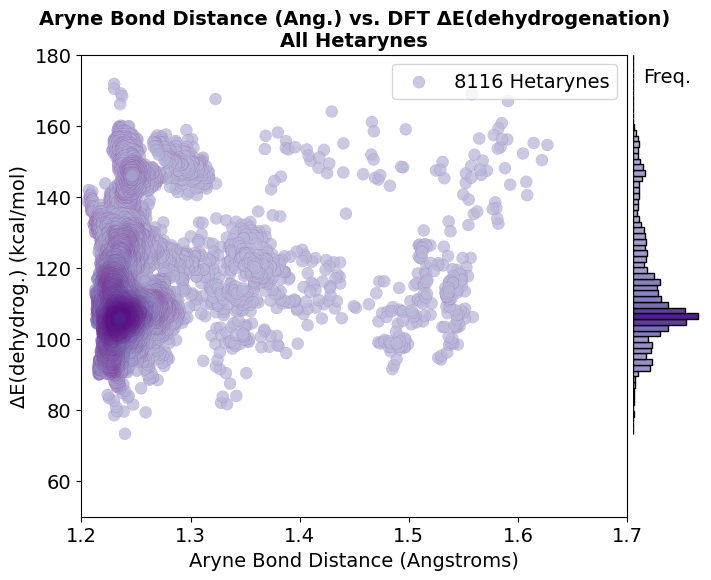

In [10]:
### Plot Aryne Bond Distance (Angstroms) vs. Dehydration Energies ###
x_angles = incoming_data['Aryne_Bond_Dist(A)']
y_energies = incoming_data['dehydrogenation_energy']

#caclulate point density for shading
xy = np.stack([x_angles, y_energies])
xy_density = gaussian_kde(xy)(xy)

#sort so most-dense points plotted last
idx = xy_density.argsort()
x_angles, y_energies, xy_density = x_angles[idx], y_energies[idx], xy_density[idx]

#Can change the color, here
my_pur = plt.cm.Purples(np.linspace(0.35,0.9,100))
my_pur = ListedColormap(my_pur[8:,:-1])

##setting up the fig with subplots###
fig = plt.figure(figsize=(8, 6))
#set the relative spacing of the two subplots
gs = fig.add_gridspec(1, 2, width_ratios=(8, 1))
plt.subplots_adjust(wspace=0.02)

#initialize the subplots in their relative positions
ax_scatter = fig.add_subplot(gs[0, 0])
ax_hist_y = fig.add_subplot(gs[0, 1])

#plot the scatter data
ax_scatter.scatter(x_angles, y_energies, c=xy_density, cmap=my_pur, linewidths=0.075, edgecolors='purple', alpha=0.75, s=75, label='8116 Hetarynes',)

#Plot Parameters for the left-side Scatterplot
ax_scatter.set_xlim(1.2,1.7)
ax_scatter.set_ylim(50,180)
ax_scatter.set_title("Aryne Bond Distance (Ang.) vs. DFT ΔE(dehydrogenation)\nAll Hetarynes", fontsize=14, fontweight='bold')
ax_scatter.set_xlabel("Aryne Bond Distance (Angstroms)", fontsize=14)
ax_scatter.set_ylabel("ΔE(dehydrog.) (kcal/mol)", fontsize=14)
ax_scatter.tick_params(axis='both', which='major', labelsize=14)
ax_scatter.legend(loc='upper right', fontsize=14)

#Plot the histogram data
m, bins, patches = ax_hist_y.hist(y_energies, bins=80, density=True, edgecolor='black', label='8116 Hetarynes', orientation='horizontal')
ax_hist_y.set_ylim(50,180)
bol = (m-m.min())/(m.max()-m.min()) #contains colormap values 
for c, p in zip(bol, patches):
    plt.setp(p, 'facecolor', my_pur(c))

#Plot Parameters for the right-side Histogram
ax_hist_y.xaxis.set_label_position('top')
ax_hist_y.set_xlabel("Freq.", fontsize=14, labelpad=-20, loc='center')
ax_hist_y.set_yticks([])
ax_hist_y.set_xticks([])
ax_hist_y.tick_params(axis="y", labelleft=False)
#remove the lines around the histo plot
ax_hist_y.spines['top'].set_visible(False)
ax_hist_y.spines['bottom'].set_visible(False)
ax_hist_y.spines['right'].set_visible(False)
ax_hist_y.spines['left'].set_visible(False)

plt.savefig('Unified_Aryne_Bond_Distance_vs_dEdehyd_with_histos.png', bbox_inches="tight", transparent=True, dpi=600)
plt.show()

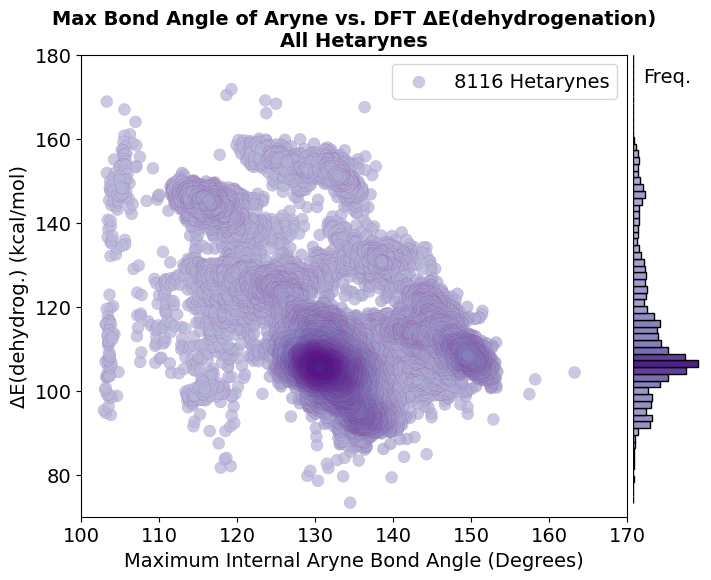

In [11]:
### Plot Maximum Internal Bond Angle vs. Dehydration Energies ###
x_angles = incoming_data['Max_Aryne_BndAngl']
y_energies = incoming_data['dehydrogenation_energy']

#caclulate point density for shading
xy = np.stack([x_angles, y_energies])
xy_density = gaussian_kde(xy)(xy)

#sort so most-dense points plotted last
idx = xy_density.argsort()
x_angles, y_energies, xy_density = x_angles[idx], y_energies[idx], xy_density[idx]

#Can change the color, here
my_pur = plt.cm.Purples(np.linspace(0.35,0.9,100))
my_pur = ListedColormap(my_pur[8:,:-1])

##setting up the fig with subplots###
fig = plt.figure(figsize=(8, 6))
#set the relative spacing of the two subplots
gs = fig.add_gridspec(1, 2, width_ratios=(8, 1))
plt.subplots_adjust(wspace=0.02)

#initialize the subplots in their relative positions
ax_scatter = fig.add_subplot(gs[0, 0])
ax_hist_y = fig.add_subplot(gs[0, 1])

#plot the scatter data
ax_scatter.scatter(x_angles, y_energies, c=xy_density, cmap=my_pur, linewidths=0.075, edgecolors='purple', alpha=0.75, s=75, label='8116 Hetarynes',)

#Plot Parameters for the left-side Scatterplot
ax_scatter.set_xlim(100,170)
ax_scatter.set_ylim(70,180)
ax_scatter.set_title("Max Bond Angle of Aryne vs. DFT ΔE(dehydrogenation)\nAll Hetarynes", fontsize=14, fontweight='bold')
ax_scatter.set_xlabel("Maximum Internal Aryne Bond Angle (Degrees)", fontsize=14)
ax_scatter.set_ylabel("ΔE(dehydrog.) (kcal/mol)", fontsize=14)
ax_scatter.tick_params(axis='both', which='major', labelsize=14)
ax_scatter.legend(loc='upper right', fontsize=14)

#Plot the histogram data
m, bins, patches = ax_hist_y.hist(y_energies, bins=80, density=True, edgecolor='black', label='8116 Hetarynes', orientation='horizontal')
ax_hist_y.set_ylim(70,180)
bol = (m-m.min())/(m.max()-m.min()) #contains colormap values 
for c, p in zip(bol, patches):
    plt.setp(p, 'facecolor', my_pur(c))

#Plot Parameters for the right-side Histogram
ax_hist_y.xaxis.set_label_position('top')
ax_hist_y.set_xlabel("Freq.", fontsize=14, labelpad=-20, loc='center')
ax_hist_y.set_yticks([])
ax_hist_y.set_xticks([])
ax_hist_y.tick_params(axis="y", labelleft=False)
#remove the lines around the histo plot
ax_hist_y.spines['top'].set_visible(False)
ax_hist_y.spines['bottom'].set_visible(False)
ax_hist_y.spines['right'].set_visible(False)
ax_hist_y.spines['left'].set_visible(False)

plt.savefig('Unified_Max_Bond_Angle_vs_dEdehyd_with_histos.png', bbox_inches="tight", transparent=True, dpi=600)
plt.show()

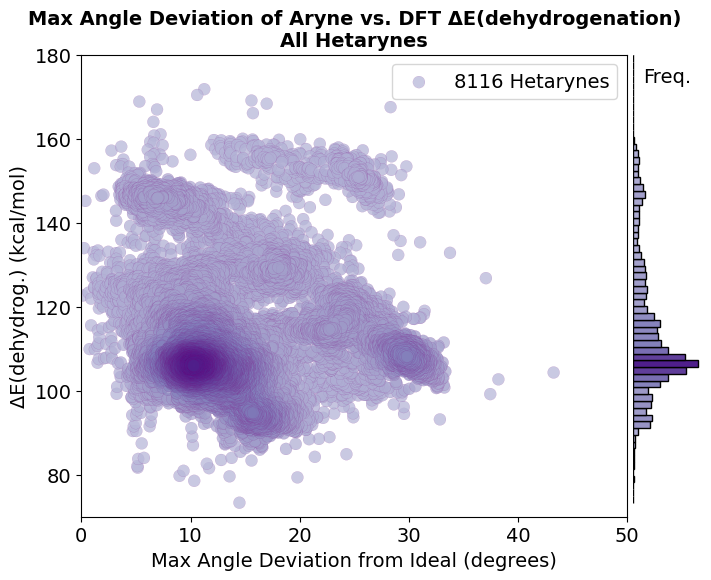

In [12]:
### Plot Aryne Maximum Angle Deviation vs. Dehydration Energies ###
x_angles = incoming_data['Max_angle_dev']
y_energies = incoming_data['dehydrogenation_energy']

#caclulate point density for shading
xy = np.stack([x_angles, y_energies])
xy_density = gaussian_kde(xy)(xy)

#sort so most-dense points plotted last
idx = xy_density.argsort()
x_angles, y_energies, xy_density = x_angles[idx], y_energies[idx], xy_density[idx]

#Can change the color, here
my_pur = plt.cm.Purples(np.linspace(0.35,0.9,100))
my_pur = ListedColormap(my_pur[8:,:-1])

##setting up the fig with subplots###
fig = plt.figure(figsize=(8, 6))
#set the relative spacing of the two subplots
gs = fig.add_gridspec(1, 2, width_ratios=(8, 1))
plt.subplots_adjust(wspace=0.02)

#initialize the subplots in their relative positions
ax_scatter = fig.add_subplot(gs[0, 0])
ax_hist_y = fig.add_subplot(gs[0, 1])

#plot the scatter data
ax_scatter.scatter(x_angles, y_energies, c=xy_density, cmap=my_pur, linewidths=0.075, edgecolors='purple', alpha=0.75, s=75, label='8116 Hetarynes',)

#Plot Parameters for the left-side Scatterplot
ax_scatter.set_xlim(0,50)
ax_scatter.set_ylim(70,180)
ax_scatter.set_title("Max Angle Deviation of Aryne vs. DFT ΔE(dehydrogenation)\nAll Hetarynes", fontsize=14, fontweight='bold')
ax_scatter.set_xlabel("Max Angle Deviation from Ideal (degrees)", fontsize=14)
ax_scatter.set_ylabel("ΔE(dehydrog.) (kcal/mol)", fontsize=14)
ax_scatter.tick_params(axis='both', which='major', labelsize=14)
ax_scatter.legend(loc='upper right', fontsize=14)

#Plot the histogram data
m, bins, patches = ax_hist_y.hist(y_energies, bins=80, density=True, edgecolor='black', label='8116 Hetarynes', orientation='horizontal')
ax_hist_y.set_ylim(70,180)
bol = (m-m.min())/(m.max()-m.min()) #contains colormap values 
for c, p in zip(bol, patches):
    plt.setp(p, 'facecolor', my_pur(c))

#Plot Parameters for the right-side Histogram
ax_hist_y.xaxis.set_label_position('top')
ax_hist_y.set_xlabel("Freq.", fontsize=14, labelpad=-20, loc='center')
ax_hist_y.set_yticks([])
ax_hist_y.set_xticks([])
ax_hist_y.tick_params(axis="y", labelleft=False)
#remove the lines around the histo plot
ax_hist_y.spines['top'].set_visible(False)
ax_hist_y.spines['bottom'].set_visible(False)
ax_hist_y.spines['right'].set_visible(False)
ax_hist_y.spines['left'].set_visible(False)

plt.savefig('Unified_Max Angle Deviation_of_Aryne_vs_dEdehyd_with_histos.png', bbox_inches="tight", transparent=True, dpi=600)
plt.show()

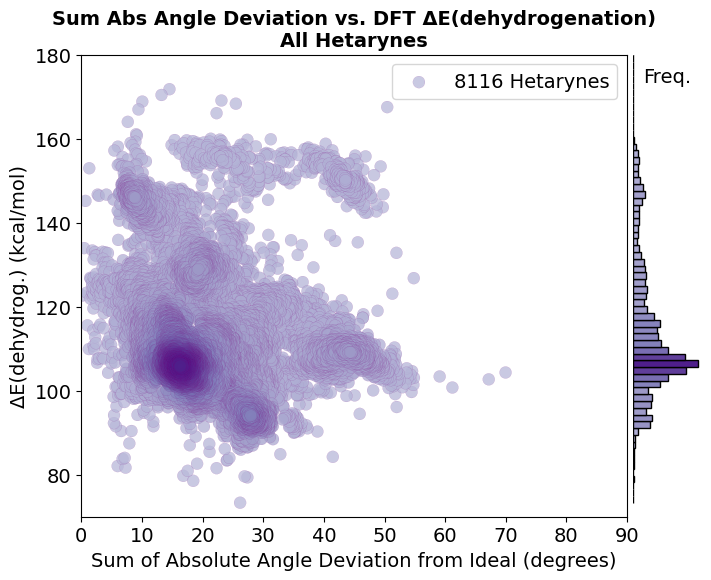

In [13]:
### Plot Aryne Sum of Absolute Deviation vs. Dehydration Energies ###
x_angles = incoming_data['Sum_abs_dev']
y_energies = incoming_data['dehydrogenation_energy']

#caclulate point density for shading
xy = np.stack([x_angles, y_energies])
xy_density = gaussian_kde(xy)(xy)

#sort so most-dense points plotted last
idx = xy_density.argsort()
x_angles, y_energies, xy_density = x_angles[idx], y_energies[idx], xy_density[idx]

#Can change the color, here
my_pur = plt.cm.Purples(np.linspace(0.35,0.9,100))
my_pur = ListedColormap(my_pur[8:,:-1])

##setting up the fig with subplots###
fig = plt.figure(figsize=(8, 6))
#set the relative spacing of the two subplots
gs = fig.add_gridspec(1, 2, width_ratios=(8, 1))
plt.subplots_adjust(wspace=0.02)

#initialize the subplots in their relative positions
ax_scatter = fig.add_subplot(gs[0, 0])
ax_hist_y = fig.add_subplot(gs[0, 1])

#plot the scatter data
ax_scatter.scatter(x_angles, y_energies, c=xy_density, cmap=my_pur, linewidths=0.075, edgecolors='purple', alpha=0.75, s=75, label='8116 Hetarynes')

#Plot Parameters for the left-side Scatterplot
ax_scatter.set_xlim(0,90)
ax_scatter.set_ylim(70,180)
ax_scatter.set_title("Sum Abs Angle Deviation vs. DFT ΔE(dehydrogenation)\nAll Hetarynes", fontsize=14, fontweight='bold')
ax_scatter.set_xlabel("Sum of Absolute Angle Deviation from Ideal (degrees)", fontsize=14)
ax_scatter.set_ylabel("ΔE(dehydrog.) (kcal/mol)", fontsize=14)
ax_scatter.tick_params(axis='both', which='major', labelsize=14)
ax_scatter.legend(loc='upper right', fontsize=14)

#Plot the histogram data
m, bins, patches = ax_hist_y.hist(y_energies, bins=80, density=True, edgecolor='black', label='8116 Hetarynes', orientation='horizontal')
ax_hist_y.set_ylim(70,180)
bol = (m-m.min())/(m.max()-m.min()) #contains colormap values 
for c, p in zip(bol, patches):
    plt.setp(p, 'facecolor', my_pur(c))

#Plot Parameters for the right-side Histogram
ax_hist_y.xaxis.set_label_position('top')
ax_hist_y.set_xlabel("Freq.", fontsize=14, labelpad=-20, loc='center')
ax_hist_y.set_yticks([])
ax_hist_y.set_xticks([])
ax_hist_y.tick_params(axis="y", labelleft=False)
#remove the lines around the histo plot
ax_hist_y.spines['top'].set_visible(False)
ax_hist_y.spines['bottom'].set_visible(False)
ax_hist_y.spines['right'].set_visible(False)
ax_hist_y.spines['left'].set_visible(False)

plt.savefig('Unified_Sum_of_Absolute_Deviation_of_Aryne_vs_dEdehyd_with_histos.png', bbox_inches="tight", transparent=True, dpi=600)
plt.show()

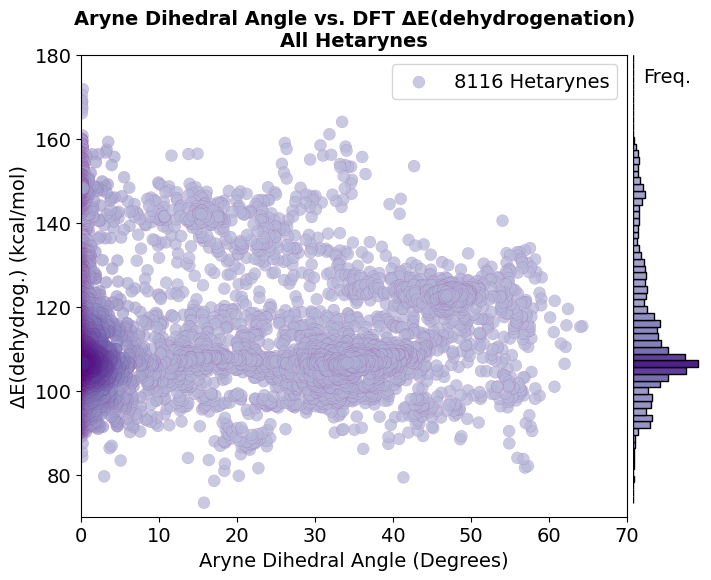

In [14]:
### Plot Aryne Dihedral Angle vs. Dehydration Energies ###
x_angles = incoming_data['Aryne_DiH_Ang']
y_energies = incoming_data['dehydrogenation_energy']

#caclulate point density for shading
xy = np.stack([x_angles, y_energies])
xy_density = gaussian_kde(xy)(xy)

#sort so most-dense points plotted last
idx = xy_density.argsort()
x_angles, y_energies, xy_density = x_angles[idx], y_energies[idx], xy_density[idx]

#Can change the color, here
my_pur = plt.cm.Purples(np.linspace(0.35,0.9,100))
my_pur = ListedColormap(my_pur[8:,:-1])

##setting up the fig with subplots###
fig = plt.figure(figsize=(8, 6))
#set the relative spacing of the two subplots
gs = fig.add_gridspec(1, 2, width_ratios=(8, 1))
plt.subplots_adjust(wspace=0.02)

#initialize the subplots in their relative positions
ax_scatter = fig.add_subplot(gs[0, 0])
ax_hist_y = fig.add_subplot(gs[0, 1])

#plot the scatter data
ax_scatter.scatter(x_angles, y_energies, c=xy_density, cmap=my_pur, linewidths=0.075, edgecolors='purple', alpha=0.75, s=75, label='8116 Hetarynes',)

#Plot Parameters for the left-side Scatterplot
ax_scatter.set_xlim(0,70)
ax_scatter.set_ylim(70,180)
ax_scatter.set_title("Aryne Dihedral Angle vs. DFT ΔE(dehydrogenation)\nAll Hetarynes", fontsize=14, fontweight='bold')
ax_scatter.set_xlabel("Aryne Dihedral Angle (Degrees)", fontsize=14)
ax_scatter.set_ylabel("ΔE(dehydrog.) (kcal/mol)", fontsize=14)
ax_scatter.tick_params(axis='both', which='major', labelsize=14)
ax_scatter.legend(loc='upper right', fontsize=14)

#Plot the histogram data
m, bins, patches = ax_hist_y.hist(y_energies, bins=80, density=True, edgecolor='black', label='8116 Hetarynes', orientation='horizontal')
ax_hist_y.set_ylim(70,180)
bol = (m-m.min())/(m.max()-m.min()) #contains colormap values 
for c, p in zip(bol, patches):
    plt.setp(p, 'facecolor', my_pur(c))
    
#Plot Parameters for the right-side Histogram
ax_hist_y.xaxis.set_label_position('top')
ax_hist_y.set_xlabel("Freq.", fontsize=14, labelpad=-20, loc='center')
ax_hist_y.set_yticks([])
ax_hist_y.set_xticks([])
ax_hist_y.tick_params(axis="y", labelleft=False)
#remove the lines around the histo plot
ax_hist_y.spines['top'].set_visible(False)
ax_hist_y.spines['bottom'].set_visible(False)
ax_hist_y.spines['right'].set_visible(False)
ax_hist_y.spines['left'].set_visible(False)

plt.savefig('Unified_Dihedral_Angle_vs_dEdehyd_with_histos.png', bbox_inches="tight", transparent=True, dpi=600)
plt.show()

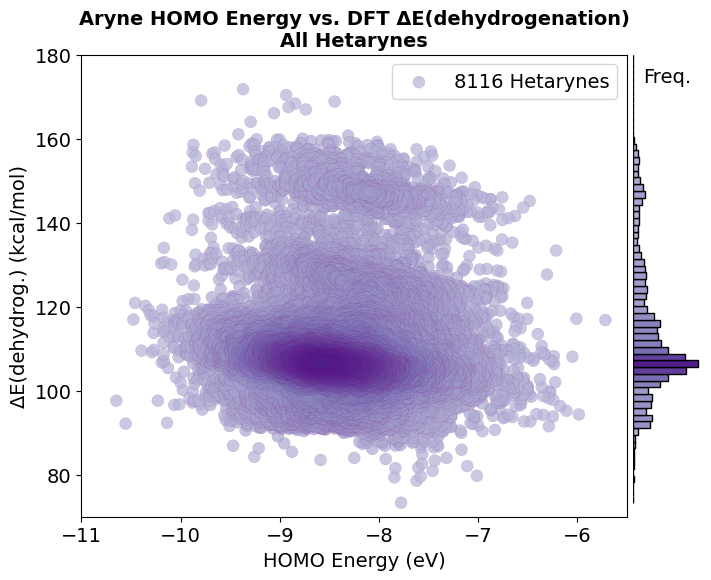

In [15]:
### Plot Aryne HOMO Energy vs. Dehydration Energies ###
x_angles = incoming_data['eHOMO(eV)']
y_energies = incoming_data['dehydrogenation_energy']

#caclulate point density for shading
xy = np.stack([x_angles, y_energies])
xy_density = gaussian_kde(xy)(xy)

#sort so most-dense points plotted last
idx = xy_density.argsort()
x_angles, y_energies, xy_density = x_angles[idx], y_energies[idx], xy_density[idx]

#Can change the color, here
my_pur = plt.cm.Purples(np.linspace(0.35,0.9,100))
my_pur = ListedColormap(my_pur[8:,:-1])

##setting up the fig with subplots###
fig = plt.figure(figsize=(8, 6))
#set the relative spacing of the two subplots
gs = fig.add_gridspec(1, 2, width_ratios=(8, 1))
plt.subplots_adjust(wspace=0.02)

#initialize the subplots in their relative positions
ax_scatter = fig.add_subplot(gs[0, 0])
ax_hist_y = fig.add_subplot(gs[0, 1])

#plot the scatter data
ax_scatter.scatter(x_angles, y_energies, c=xy_density, cmap=my_pur, linewidths=0.075, edgecolors='purple', alpha=0.75, s=75, label='8116 Hetarynes',)

#Plot Parameters for the left-side Scatterplot
ax_scatter.set_xlim(-11,-5.5)
ax_scatter.set_ylim(70,180)
ax_scatter.set_title("Aryne HOMO Energy vs. DFT ΔE(dehydrogenation)\nAll Hetarynes", fontsize=14, fontweight='bold')
ax_scatter.set_xlabel("HOMO Energy (eV)", fontsize=14)
ax_scatter.set_ylabel("ΔE(dehydrog.) (kcal/mol)", fontsize=14)
ax_scatter.tick_params(axis='both', which='major', labelsize=14)
ax_scatter.legend(loc='upper right', fontsize=14)

#Plot the histogram data
m, bins, patches = ax_hist_y.hist(y_energies, bins=80, density=True, edgecolor='black', label='8116 Hetarynes', orientation='horizontal')
ax_hist_y.set_ylim(70,180)
bol = (m-m.min())/(m.max()-m.min()) #contains colormap values 
for c, p in zip(bol, patches):
    plt.setp(p, 'facecolor', my_pur(c))

#Plot Parameters for the right-side Histogram
ax_hist_y.xaxis.set_label_position('top')
ax_hist_y.set_xlabel("Freq.", fontsize=14, labelpad=-20, loc='center')
ax_hist_y.set_yticks([])
ax_hist_y.set_xticks([])
ax_hist_y.tick_params(axis="y", labelleft=False)
#remove the lines around the histo plot
ax_hist_y.spines['top'].set_visible(False)
ax_hist_y.spines['bottom'].set_visible(False)
ax_hist_y.spines['right'].set_visible(False)
ax_hist_y.spines['left'].set_visible(False)

plt.savefig('Unified_Aryne_HOMO_Energy_vs_dEdehyd_with_histos.png', bbox_inches="tight", transparent=True, dpi=600)
plt.show()

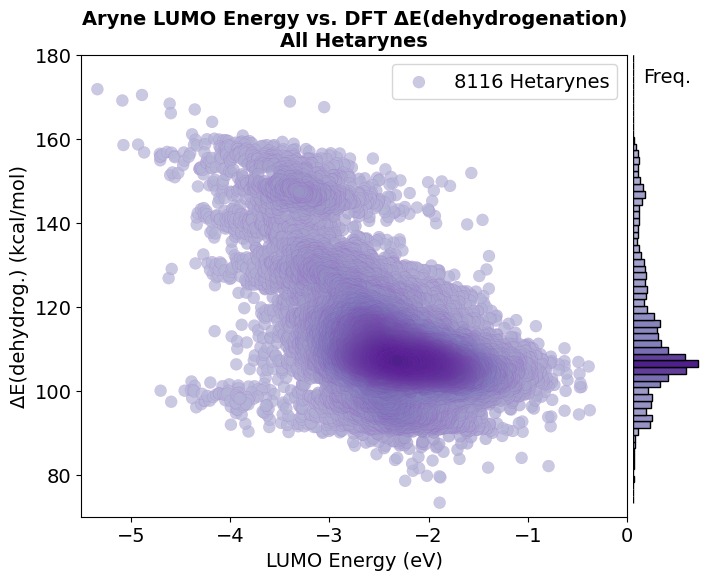

In [16]:
### Plot Aryne LUMO Energy vs. Dehydration Energies ###
x_angles = incoming_data['eLUMO(eV)']
y_energies = incoming_data['dehydrogenation_energy']

#caclulate point density for shading
xy = np.stack([x_angles, y_energies])
xy_density = gaussian_kde(xy)(xy)

#sort so most-dense points plotted last
idx = xy_density.argsort()
x_angles, y_energies, xy_density = x_angles[idx], y_energies[idx], xy_density[idx]

#Can change the color, here
my_pur = plt.cm.Purples(np.linspace(0.35,0.9,100))
my_pur = ListedColormap(my_pur[8:,:-1])

##setting up the fig with subplots###
fig = plt.figure(figsize=(8, 6))
#set the relative spacing of the two subplots
gs = fig.add_gridspec(1, 2, width_ratios=(8, 1))
plt.subplots_adjust(wspace=0.02)

#initialize the subplots in their relative positions
ax_scatter = fig.add_subplot(gs[0, 0])
ax_hist_y = fig.add_subplot(gs[0, 1])

#plot the scatter data
ax_scatter.scatter(x_angles, y_energies, c=xy_density, cmap=my_pur, linewidths=0.075, edgecolors='darkorchid', alpha=0.75, s=75, label='8116 Hetarynes',)

#Plot Parameters for the left-side Scatterplot
ax_scatter.set_xlim(-5.5,0)
ax_scatter.set_ylim(70,180)
ax_scatter.set_title("Aryne LUMO Energy vs. DFT ΔE(dehydrogenation)\nAll Hetarynes", fontsize=14, fontweight='bold')
ax_scatter.set_xlabel("LUMO Energy (eV)", fontsize=14)
ax_scatter.set_ylabel("ΔE(dehydrog.) (kcal/mol)", fontsize=14)
ax_scatter.tick_params(axis='both', which='major', labelsize=14)
#ax_scatter.yaxis.tick_left()
ax_scatter.legend(loc='upper right', fontsize=14)

#Plot the histogram data
m, bins, patches = ax_hist_y.hist(y_energies, bins=80, density=True, edgecolor='black', label='8116 Hetarynes', orientation='horizontal')
ax_hist_y.set_ylim(70,180)
bol = (m-m.min())/(m.max()-m.min()) #contains colormap values 
for c, p in zip(bol, patches):
    plt.setp(p, 'facecolor', my_pur(c))

#Plot Parameters for the right-side Histogram
ax_hist_y.xaxis.set_label_position('top')
ax_hist_y.set_xlabel("Freq.", fontsize=14, labelpad=-20, loc='center')
ax_hist_y.set_yticks([])
ax_hist_y.set_xticks([])
ax_hist_y.tick_params(axis="y", labelleft=False)
#remove the lines around the histo plot
ax_hist_y.spines['top'].set_visible(False)
ax_hist_y.spines['bottom'].set_visible(False)
ax_hist_y.spines['right'].set_visible(False)
ax_hist_y.spines['left'].set_visible(False)

plt.savefig('Unified_Aryne_LUMO_Energy_vs_dEdehyd_with_histos.png', bbox_inches="tight", transparent=True, dpi=600)
plt.show()

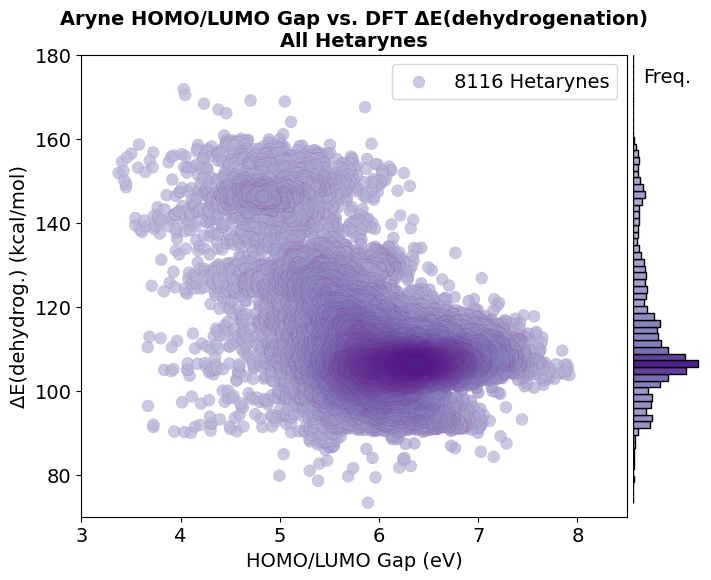

In [17]:
### Plot Aryne HOMO/LUMO Gap Energy vs. Dehydration Energies ###
x_angles = incoming_data['H_L_Gap(eV)']
y_energies = incoming_data['dehydrogenation_energy']

#caclulate point density for shading
xy = np.stack([x_angles, y_energies])
xy_density = gaussian_kde(xy)(xy)

#sort so most-dense points plotted last
idx = xy_density.argsort()
x_angles, y_energies, xy_density = x_angles[idx], y_energies[idx], xy_density[idx]

#Can change the color, here
my_pur = plt.cm.Purples(np.linspace(0.35,0.9,100))
my_pur = ListedColormap(my_pur[8:,:-1])

##setting up the fig with subplots###
fig = plt.figure(figsize=(8, 6))
#set the relative spacing of the two subplots
gs = fig.add_gridspec(1, 2, width_ratios=(8, 1))
plt.subplots_adjust(wspace=0.02)

#initialize the subplots in their relative positions
ax_scatter = fig.add_subplot(gs[0, 0])
ax_hist_y = fig.add_subplot(gs[0, 1])

#plot the scatter data
ax_scatter.scatter(x_angles, y_energies, c=xy_density, cmap=my_pur, linewidths=0.075, edgecolors='purple', alpha=0.75, s=75, label='8116 Hetarynes',)

#Plot Parameters for the left-side Scatterplot
ax_scatter.set_xlim(3,8.5)
ax_scatter.set_ylim(70,180)
ax_scatter.set_title("Aryne HOMO/LUMO Gap vs. DFT ΔE(dehydrogenation)\nAll Hetarynes", fontsize=14, fontweight='bold')
ax_scatter.set_xlabel("HOMO/LUMO Gap (eV)", fontsize=14)
ax_scatter.set_ylabel("ΔE(dehydrog.) (kcal/mol)", fontsize=14)
ax_scatter.tick_params(axis='both', which='major', labelsize=14)
ax_scatter.legend(loc='upper right', fontsize=14)

#Plot the histogram data
m, bins, patches = ax_hist_y.hist(y_energies, bins=80, density=True, edgecolor='black', label='8116 Hetarynes', orientation='horizontal')
ax_hist_y.set_ylim(70,180)
bol = (m-m.min())/(m.max()-m.min()) #contains colormap values 
for c, p in zip(bol, patches):
    plt.setp(p, 'facecolor', my_pur(c))

#Plot Parameters for the right-side Histogram
ax_hist_y.xaxis.set_label_position('top')
ax_hist_y.set_xlabel("Freq.", fontsize=14, labelpad=-20, loc='center')
ax_hist_y.set_yticks([])
ax_hist_y.set_xticks([])
ax_hist_y.tick_params(axis="y", labelleft=False)
#remove the lines around the histo plot
ax_hist_y.spines['top'].set_visible(False)
ax_hist_y.spines['bottom'].set_visible(False)
ax_hist_y.spines['right'].set_visible(False)
ax_hist_y.spines['left'].set_visible(False)

plt.savefig('Unified_Aryne_HOMO-LUMO_Gap_vs_dEdehyd_with_histos.png', bbox_inches="tight", transparent=True, dpi=600)
plt.show()

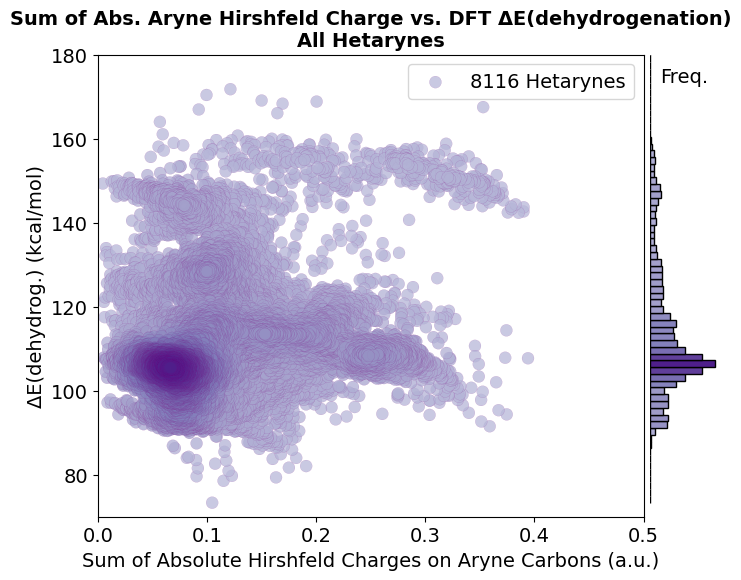

In [18]:
### Plot Aryne Hirshfeld Summed Charge Across Aryne Carbons vs. Dehydration Energies ###
x_angles = incoming_data['Sum_Abs_Hirsh_aryne']
y_energies = incoming_data['dehydrogenation_energy']

#caclulate point density for shading
xy = np.stack([x_angles, y_energies])
xy_density = gaussian_kde(xy)(xy)

#sort so most-dense points plotted last
idx = xy_density.argsort()
x_angles, y_energies, xy_density = x_angles[idx], y_energies[idx], xy_density[idx]

#Can change the color, here
my_pur = plt.cm.Purples(np.linspace(0.35,0.9,100))
my_pur = ListedColormap(my_pur[8:,:-1])

##setting up the fig with subplots###
fig = plt.figure(figsize=(8, 6))
#set the relative spacing of the two subplots
gs = fig.add_gridspec(1, 2, width_ratios=(8, 1))
plt.subplots_adjust(wspace=0.02)

#initialize the subplots in their relative positions
ax_scatter = fig.add_subplot(gs[0, 0])
ax_hist_y = fig.add_subplot(gs[0, 1])

#plot the scatter data
ax_scatter.scatter(x_angles, y_energies, c=xy_density, cmap=my_pur, linewidths=0.075, edgecolors='purple', alpha=0.75, s=75, label='8116 Hetarynes',)

#Plot Parameters for the left-side Scatterplot
ax_scatter.set_xlim(0, 0.5)
ax_scatter.set_ylim(70,180)
ax_scatter.set_title("Sum of Abs. Aryne Hirshfeld Charge vs. DFT ΔE(dehydrogenation)\nAll Hetarynes", fontsize=14, fontweight='bold')
ax_scatter.set_xlabel("Sum of Absolute Hirshfeld Charges on Aryne Carbons (a.u.)", fontsize=14)
ax_scatter.set_ylabel("ΔE(dehydrog.) (kcal/mol)", fontsize=14)
ax_scatter.tick_params(axis='both', which='major', labelsize=14)
ax_scatter.legend(loc='upper right', fontsize=14)

#Plot the histogram data
m, bins, patches = ax_hist_y.hist(y_energies, bins=80, density=True, edgecolor='black', label='8116 Hetarynes', orientation='horizontal')
ax_hist_y.set_ylim(70,180)
bol = (m-m.min())/(m.max()-m.min()) #contains colormap values 
for c, p in zip(bol, patches):
    plt.setp(p, 'facecolor', my_pur(c))

#Plot Parameters for the right-side Histogram
ax_hist_y.xaxis.set_label_position('top')
ax_hist_y.set_xlabel("Freq.", fontsize=14, labelpad=-20, loc='center')
ax_hist_y.set_yticks([])
ax_hist_y.set_xticks([])
ax_hist_y.tick_params(axis="y", labelleft=False)
#remove the lines around the histo plot
ax_hist_y.spines['top'].set_visible(False)
ax_hist_y.spines['bottom'].set_visible(False)
ax_hist_y.spines['right'].set_visible(False)
ax_hist_y.spines['left'].set_visible(False)

plt.savefig('Unified_Sum_absHirsh_vs_dEdehyd_with_histos.png', bbox_inches="tight", transparent=True, dpi=600)
plt.show()